In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('telco.csv')
df.head(5)

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [ ]:
df.shape

(7043, 50)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

The dataset contains 7043 observations and 50 features. Features include demographic, service usage, contract information, and customer engagement variables.

**Dataset information**

*Customer Information*
* CustomerID: A unique ID for each customer.
* Gender: Male or Female.
* Age: Customer’s age in years.
* Senior Citizen: Yes if 65 or older, No otherwise.
* Married: Yes/No.
* Dependents: Yes/No; indicates if the customer has dependents.
* Number of Dependents: Number of dependents living with the customer.
* Country / State / City / Zip Code / Latitude / Longitude: Customer's primary residence information.
* Population: Estimated population in the customer’s Zip Code area.

*Account Information*
* Quarter: Fiscal quarter of data (e.g., Q3).
* Referred a Friend: Yes/No; indicates if the customer referred someone.
* Number of Referrals: Total referrals made by the customer.
* Tenure in Months: Total months with the company.
* Offer: Last marketing offer accepted (None, Offer A-E).

*Services and Usage*
* Phone Service: Yes/No.
* Avg Monthly Long Distance Charges: Average charges for long distance calls.
* Multiple Lines: Yes/No.
* Internet Service: Type of internet service (No, DSL, Fiber Optic, Cable).
* Avg Monthly GB Download: Average monthly download in GB.
* Online Security, Online Backup, Device Protection Plan, Premium Tech Support: Yes/No.
* Streaming TV / Movies / Music: Yes/No.
* Unlimited Data: Yes/No.

*Billing and Payments*
* Contract: Month-to-Month, One Year, Two Year.
* Paperless Billing: Yes/No.
* Payment Method: Bank Withdrawal, Credit Card, Mailed Check.
* Monthly Charge, Total Charges, Total Refunds, Total Extra Data Charges, Total Long Distance Charges: Billing-related metrics.

*Customer Satisfaction*
* Satisfaction Score: Rating from 1 (Very Unsatisfied) to 5 (Very Satisfied).
* Satisfaction Score Label: Text version of the rating.

*Churn Information*
* Customer Status: Churned, Stayed, or Joined.
* Churn Label / Value: Yes/No or 1/0; indicates if the customer left the company.
* Churn Score: 0-100 predictive score from IBM SPSS Modeler.
* Churn Score Category: Categories based on score ranges.
* CLTV / CLTV Category: Customer Lifetime Value and its category.
* Churn Category / Reason: Reason for customer churn, e.g., Price, Competitor, Dissatisfaction, Other, Attitude

In [3]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", numerical_cols)

# Categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

Numerical columns: ['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV']
Categorical columns: ['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Country', 'State', 'City', 'Quarter', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Label', 'Churn Category', 'Churn Reason']


In [4]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Customer ID: 7043 unique values
Gender: 2 unique values
Under 30: 2 unique values
Senior Citizen: 2 unique values
Married: 2 unique values
Dependents: 2 unique values
Country: 1 unique values
State: 1 unique values
City: 1106 unique values
Quarter: 1 unique values
Referred a Friend: 2 unique values
Offer: 5 unique values
Phone Service: 2 unique values
Multiple Lines: 2 unique values
Internet Service: 2 unique values
Internet Type: 3 unique values
Online Security: 2 unique values
Online Backup: 2 unique values
Device Protection Plan: 2 unique values
Premium Tech Support: 2 unique values
Streaming TV: 2 unique values
Streaming Movies: 2 unique values
Streaming Music: 2 unique values
Unlimited Data: 2 unique values
Contract: 3 unique values
Paperless Billing: 2 unique values
Payment Method: 3 unique values
Customer Status: 3 unique values
Churn Label: 2 unique values
Churn Category: 5 unique values
Churn Reason: 20 unique values


In [5]:
#Checking our target variable: Churn Label (will be changed to just Churn later on)
# Target distribution (raw counts)
df['Churn Label'].value_counts()


# Target distribution (percentages)
df['Churn Label'].value_counts(normalize=True) * 100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


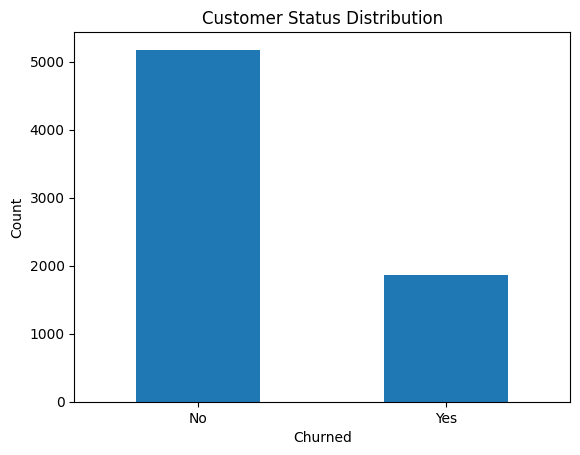

In [6]:
# Visual
df['Churn Label'].value_counts().plot(kind='bar')
plt.title('Customer Status Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

The target variable exhibits moderate class imbalance, with approximately 27% churn rate.

# Numerical Understanding

## Missing Values

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Under 30,0
Senior Citizen,0
Married,0
Dependents,0
Number of Dependents,0
Country,0
State,0


**Missing Values**

Offer- 3877
* Domain: Identifies the last marketing offer that the customer accepted, if applicable. Values include None, Offer A, Offer B, Offer C, Offer D, and Offer E.
* Handling Method: best case is creating a new value as [Unknown].


Internet Type	- 1526
* Domain: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.
* Handling Method: best case is creating a new value as [Unknown].

Churn Category and Churn Reason - 5174
* Reason for missing is that the person has not left the company or Churned, these values are derived from the Churn Label.

In [7]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

## Outliers

In [8]:
# Select only numeric columns
outlier_summary = {}
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "outlier_count": outliers.shape[0]}

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                                   lower_bound  upper_bound  outlier_count
Age                                     -10.00       102.00            0.0
Number of Dependents                      0.00         0.00         1627.0
Zip Code                              87259.00    100171.00            0.0
Latitude                                 27.73        44.42            0.0
Longitude                              -127.52      -112.24            0.0
Population                           -48327.50     86796.50           57.0
Number of Referrals                      -4.50         7.50          676.0
Tenure in Months                        -60.00       124.00            0.0
Avg Monthly Long Distance Charges       -31.57        77.17            0.0
Avg Monthly GB Download                 -33.00        63.00          362.0
Monthly Charge                          -46.02       171.38            0.0
Total Charges                         -4679.52      8866.28            0.0
Total Refunds            

## Mean, Median, and Skewness

In [9]:
import pandas as pd
import numpy as np

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Remove binary numeric columns (only 2 unique values)
non_binary_numeric = [
    col for col in numeric_cols
    if df[col].nunique() > 2
]

non_binary_numeric

['Age',
 'Number of Dependents',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Score',
 'CLTV']

In [10]:
# Finding Mean, Median and Skewness
summary_stats = pd.DataFrame({
    "Mean": df[non_binary_numeric].mean(),
    "Median": df[non_binary_numeric].median(),
    "Skewness": df[non_binary_numeric].skew()
})

summary_stats.sort_values(by="Skewness", ascending=False)

,Mean,Median,Skewness
Total Refunds,1.962182,0.000000,4.328517
Total Extra Data Charges,6.860713,0.000000,4.091209
Number of Dependents,0.468692,0.000000,2.109932
Number of Referrals,1.951867,0.000000,1.446060
Total Long Distance Charges,749.099262,401.440000,1.238282
Avg Monthly GB Download,20.515405,17.000000,1.216584
Total Charges,2280.381264,1394.550000,0.963791
Total Revenue,3034.379056,2108.640000,0.919410
Population,22139.603294,17554.000000,0.912854
Latitude,36.197455,36.205465,0.314804


**Skewness**
- Total Refunds: Highly Skewed
- Total Extra Data Changes: Highly Skewed
- Number of Dependents: Highly Skewed
- Number of Referrals: Highly Skewed
- Total Long Distance Charges: Skewed
- Avg Monthly GB Download: Skewed
- Total Charges: Skewed
- Total Revenue: Skewed
- Population: Skewed
- Tenure in Months: Symmetric
- Age: Symmetric
- Avg Monthly Long Distance Charges: Symmetric
- Churn Score: Symmetric
- Monthly Charge: Symmetric
- CLTV: Symmetric
- Satisfaction Socre: Symmetric

**Insights from Numerical Data**

After examining the descriptive statistics of the numerical features, the following insights can be drawn:

*Age:*

Mean age of customers is ~46.5 years.
Standard deviation is ~16.75, indicating a moderately wide spread.
Youngest customer is 19 and oldest is 80, showing a diverse age range.

*Number of Dependents:*

Most customers have 0 dependents (median = 0).
Maximum number of dependents is 9, but mean is only ~0.47, suggesting most customers live alone or with few dependents.

*Location (Zip Code, Latitude, Longitude, Population):*

Zip Codes range from 90001 to 96150.
Latitude and Longitude indicate coverage across multiple states.
Population varies widely from 11 to 105,285 per area.

*Customer Engagement:*

Number of Referrals: Most customers have referred 0 people; maximum referrals = 11.

Tenure in Months: Average tenure is ~32 months, ranging from 1 to 72 months.

*Service Usage and Billing:*

Avg Monthly Long Distance Charges: Mean ~22.96, maximum ~50.

Avg Monthly GB Download: Mean ~20.52 GB; some customers download up to 85 GB.

Monthly Charges: Average monthly bill ~64.76, with a max of 118.75.

Total Charges: Mean ~2,280, but max ~8,684, showing some high-value customers.

Total Refunds, Extra Data, Long Distance Charges: Some customers have unusually high extra charges, suggesting outliers.

*Customer Metrics:*

Satisfaction Score: Average score ~3.24, ranging 1–5.

Churn Score: Mean ~58.5, max 96, showing that some customers are highly likely to churn.

CLTV (Customer Lifetime Value): Average ~4,400; high CLTV customers (max 6,500) are critical for retention.

*Observations:*

Many numerical features are moderately skewed (e.g., Tenure, Total Charges, Extra Charges).
There are clear outliers in several columns (Population, Total Charges, Extra Data Charges, Long Distance Charges).
Most customers have low numbers of dependents and referrals.
High churn risk customers can be identified using Churn Score and high-value customers using CLTV.

## Target vs Feature Analysis

In [11]:
df.groupby("Churn Label")[non_binary_numeric].mean()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
Churn Label,,,,,,,,,,,,,,,,,,,
No,45.344414,0.595284,93504.246811,36.259100,-119.787825,21483.028991,2.468690,37.591225,22.883572,19.915733,61.265124,2550.792103,2.122279,6.752996,862.952107,3418.374927,3.789911,50.098183,4490.921337
Yes,49.735688,0.118245,93435.752809,36.026801,-119.670474,23957.214553,0.521134,17.979133,23.167635,22.175495,74.441332,1531.796094,1.518983,7.158909,433.917549,1971.353569,1.736223,81.777956,4149.414660


Look for:

Is tenure lower for churners?
Tenure in Months: [0] has 37.59 and [1] has 17.98

Is satisfaction lower?
Satisfaction Score: [0] has 3.78 and [1] has 1.73

Is monthly charge higher?
Monthly Charge: [0] has 61.26
and [1] has 74.44

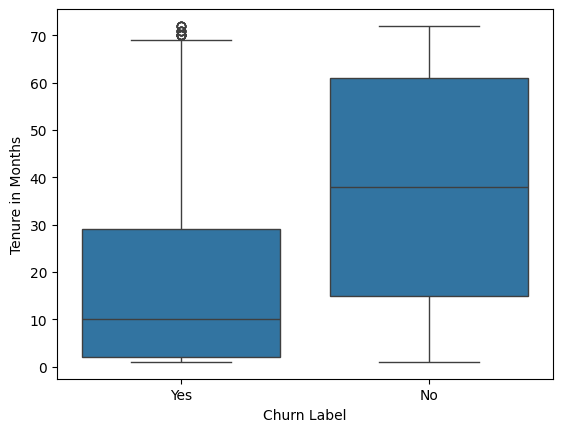

In [ ]:
# Boxplot of Distribution by Churn and Tenure
sns.boxplot(x="Churn Label", y="Tenure in Months", data=df)
plt.show()

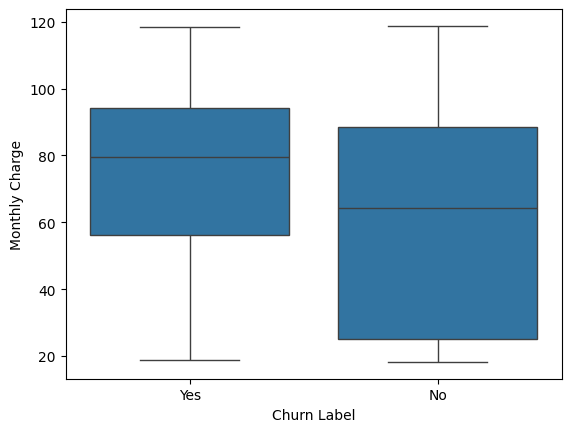

In [ ]:
sns.boxplot(x="Churn Label", y="Monthly Charge", data=df)
plt.show()

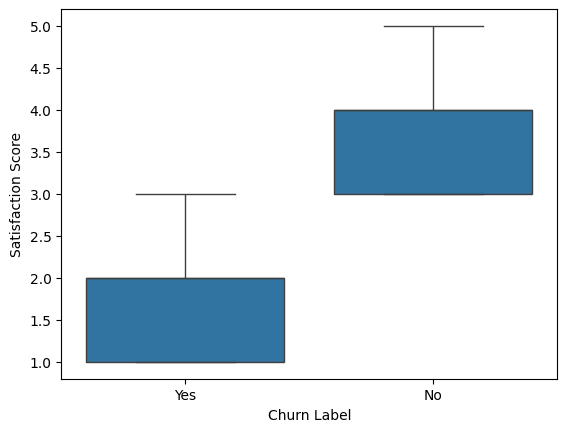

In [ ]:
sns.boxplot(x="Churn Label", y="Satisfaction Score", data=df)
plt.show()

# Categorical Understanding

In [12]:
# Check Churn rate by category
pd.crosstab(df["Contract"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


Contract type shows a strong relationship with churn behavior. Customers on month-to-month contracts exhibit significantly higher churn rates (45.8%) compared to those on one-year (10.7%) and two-year contracts (2.5%), indicating contract duration plays a critical role in customer retention.

In [ ]:
# Check Churn rate by category
pd.crosstab(df["Payment Method"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Payment Method,,
Bank Withdrawal,66.001535,33.998465
Credit Card,85.522008,14.477992
Mailed Check,63.116883,36.883117


Payment method shows a clear relationship with churn. Customers paying via mailed check exhibit the highest churn rate (36.9%), followed by bank withdrawal (34.0%), while credit card users show significantly lower churn (14.5%). This suggests that customers using digital and automated payment methods are more likely to remain with the company.

In [ ]:
# Check Churn rate by category
pd.crosstab(df["Internet Service"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Internet Service,,
No,92.595020,7.404980
Yes,68.171107,31.828893


Customers subscribed to internet services exhibit significantly higher churn rates (31.8%) compared to those without internet service (7.4%), suggesting that churn risk is concentrated among higher-engagement service users.

In [ ]:
# Check Churn rate by category
pd.crosstab(df["Satisfaction Score"], df["Churn Label"], normalize="index") * 100

Churn Label,No,Yes
Satisfaction Score,,
1,0.000000,100.000000
2,0.000000,100.000000
3,83.902439,16.097561
4,100.000000,0.000000
5,100.000000,0.000000


Satisfaction Score was found to have a near-deterministic relationship with churn. This indicates potential target leakage. Therefore, it was excluded from modeling to ensure realistic predictive performance.

# Tenure vs Churn

In [ ]:
pd.qcut(df["Tenure in Months"], 4)

,Tenure in Months
0,"(0.999, 9.0]"
1,"(0.999, 9.0]"
2,"(9.0, 29.0]"
3,"(9.0, 29.0]"
4,"(29.0, 55.0]"
...,...
7038,"(55.0, 72.0]"
7039,"(9.0, 29.0]"
7040,"(55.0, 72.0]"
7041,"(9.0, 29.0]"


In [ ]:
pd.crosstab(
    pd.qcut(df["Tenure in Months"], 4),
    df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Tenure in Months,,
"(0.999, 9.0]",49.918611,50.081389
"(9.0, 29.0]",71.842410,28.157590
"(29.0, 55.0]",81.151832,18.848168
"(55.0, 72.0]",92.250712,7.749288


Early customers (0–9 months):
→ 50% churn

Long-term customers (55+ months):
→ 7.7% churn

That’s over a 6× reduction in churn risk.

**This is textbook churn behavior:**

* High churn early

* Stabilization over time

* Loyalty builds with tenure

# Data Vizualition

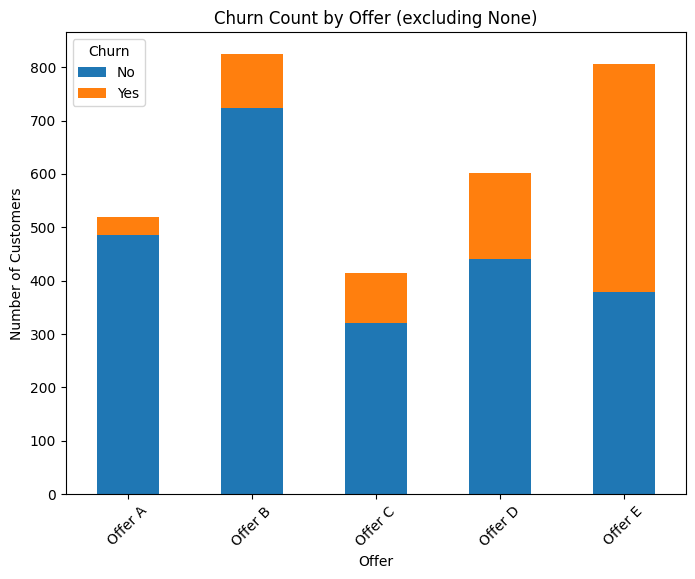

In [ ]:
# Offers
offer_churn = pd.crosstab(df.loc[df['Offer'] != "None", 'Offer'], df['Churn Label'])

offer_churn.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Churn Count by Offer (excluding None)")
plt.xlabel("Offer")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()

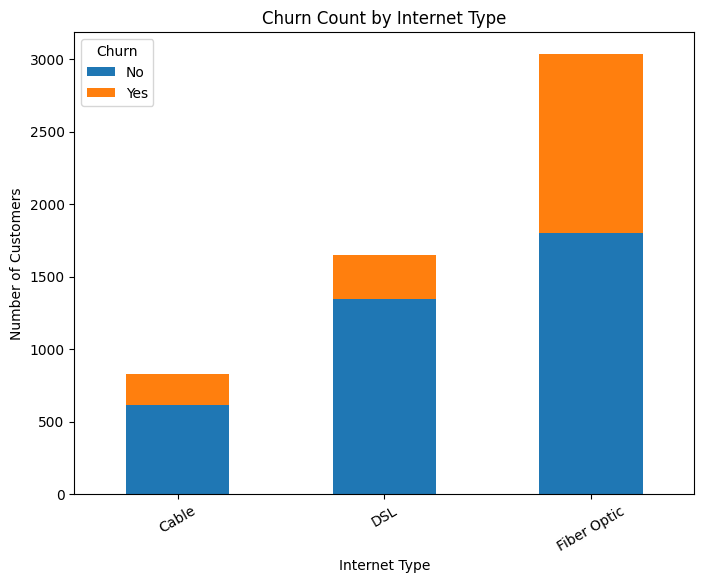

In [ ]:
# Internet Type
offer_churn = pd.crosstab(df['Internet Type'], df['Churn Label'])

offer_churn.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Churn Count by Internet Type")
plt.xlabel("Internet Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn", labels=["No", "Yes"])
plt.xticks(rotation=30)
plt.show()

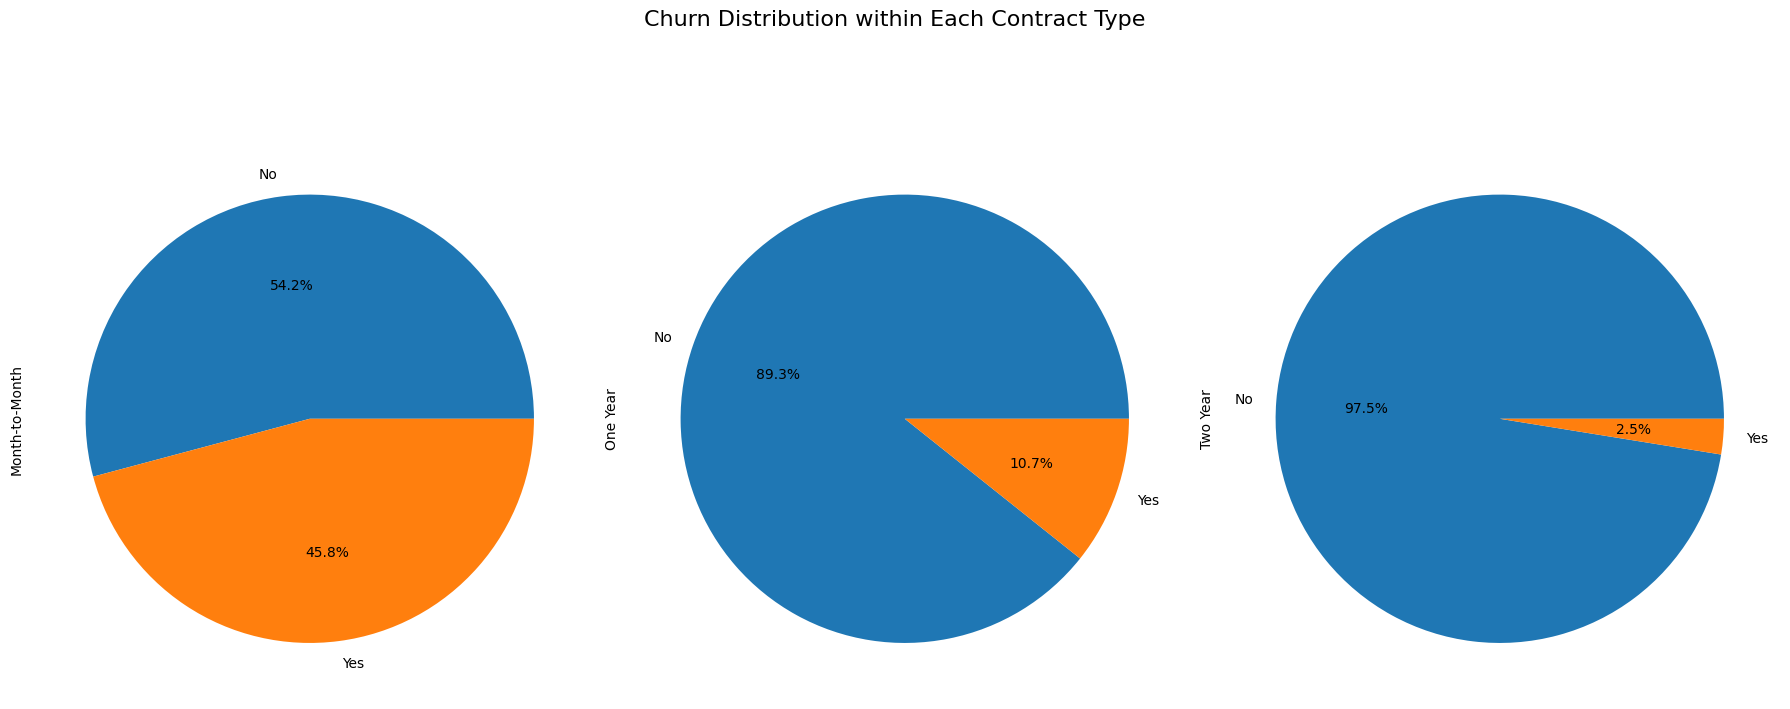

In [14]:
# Churn Distribution
contract_churn = pd.crosstab(df['Churn Label'], df['Contract'])

# 2. Plotting
# We plot the transpose so that each 'Contract' becomes its own subplot (pie)
contract_churn.plot(kind='pie',
                    subplots=True,
                    figsize=(18, 8),
                    autopct="%.1f%%",
                    legend=False)

plt.suptitle("Churn Distribution within Each Contract Type", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for title
plt.show()

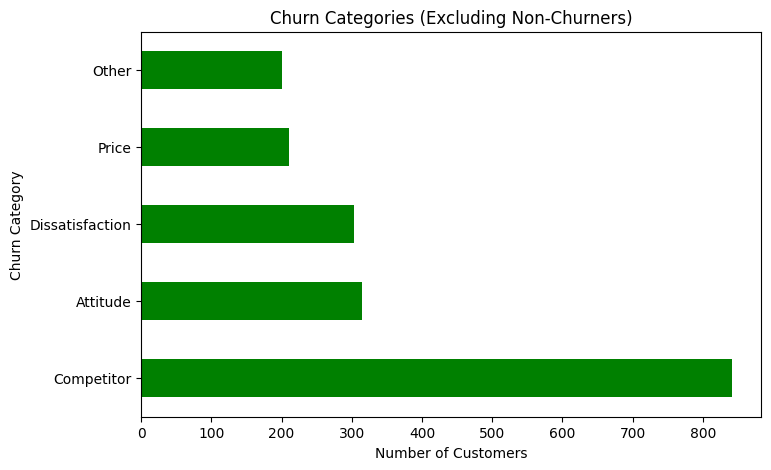

In [ ]:
# Churn Category
df['Churn Category'].value_counts().plot(kind='barh', figsize=(8,5), color="green")

plt.title("Churn Categories (Excluding Non-Churners)")
plt.xlabel("Number of Customers")
plt.ylabel("Churn Category")
plt.show()

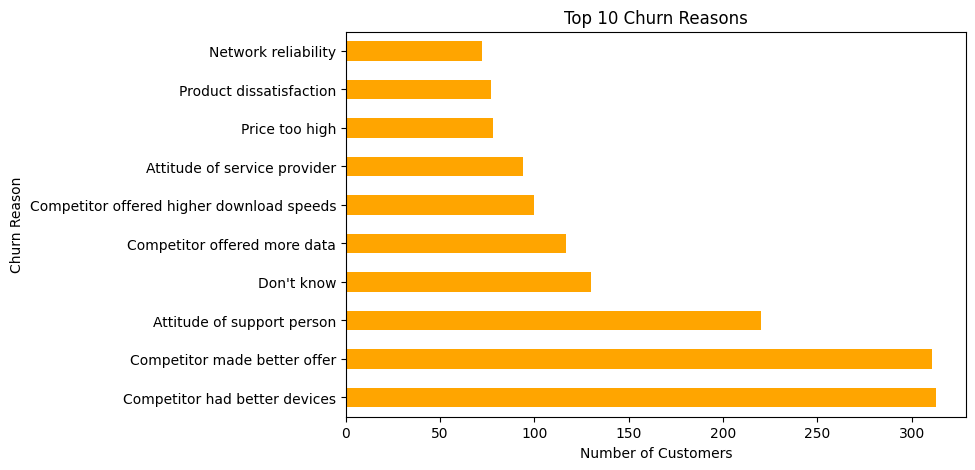

In [ ]:
# Churn Reason
df['Churn Reason'].value_counts().head(10).plot(kind='barh', figsize=(8,5), color="orange")
plt.title("Top 10 Churn Reasons")
plt.xlabel("Number of Customers")
plt.show()

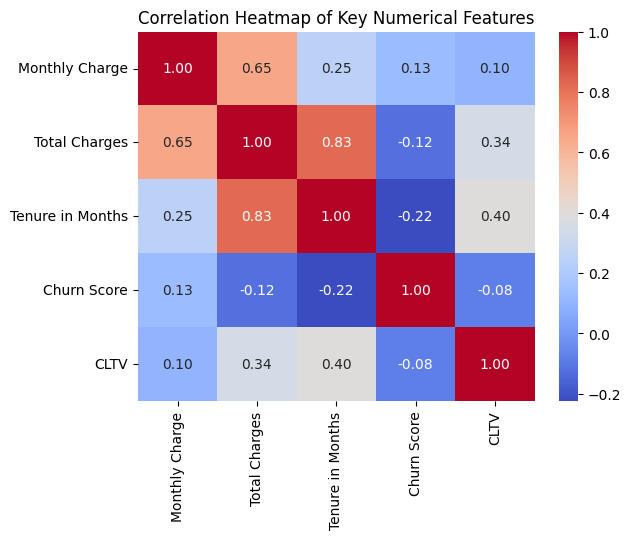

In [ ]:
# Correlation Heatmap
numerical_features = ['Monthly Charge','Total Charges','Tenure in Months','Churn Score','CLTV']
corr = df[numerical_features].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Key Numerical Features')
plt.show()

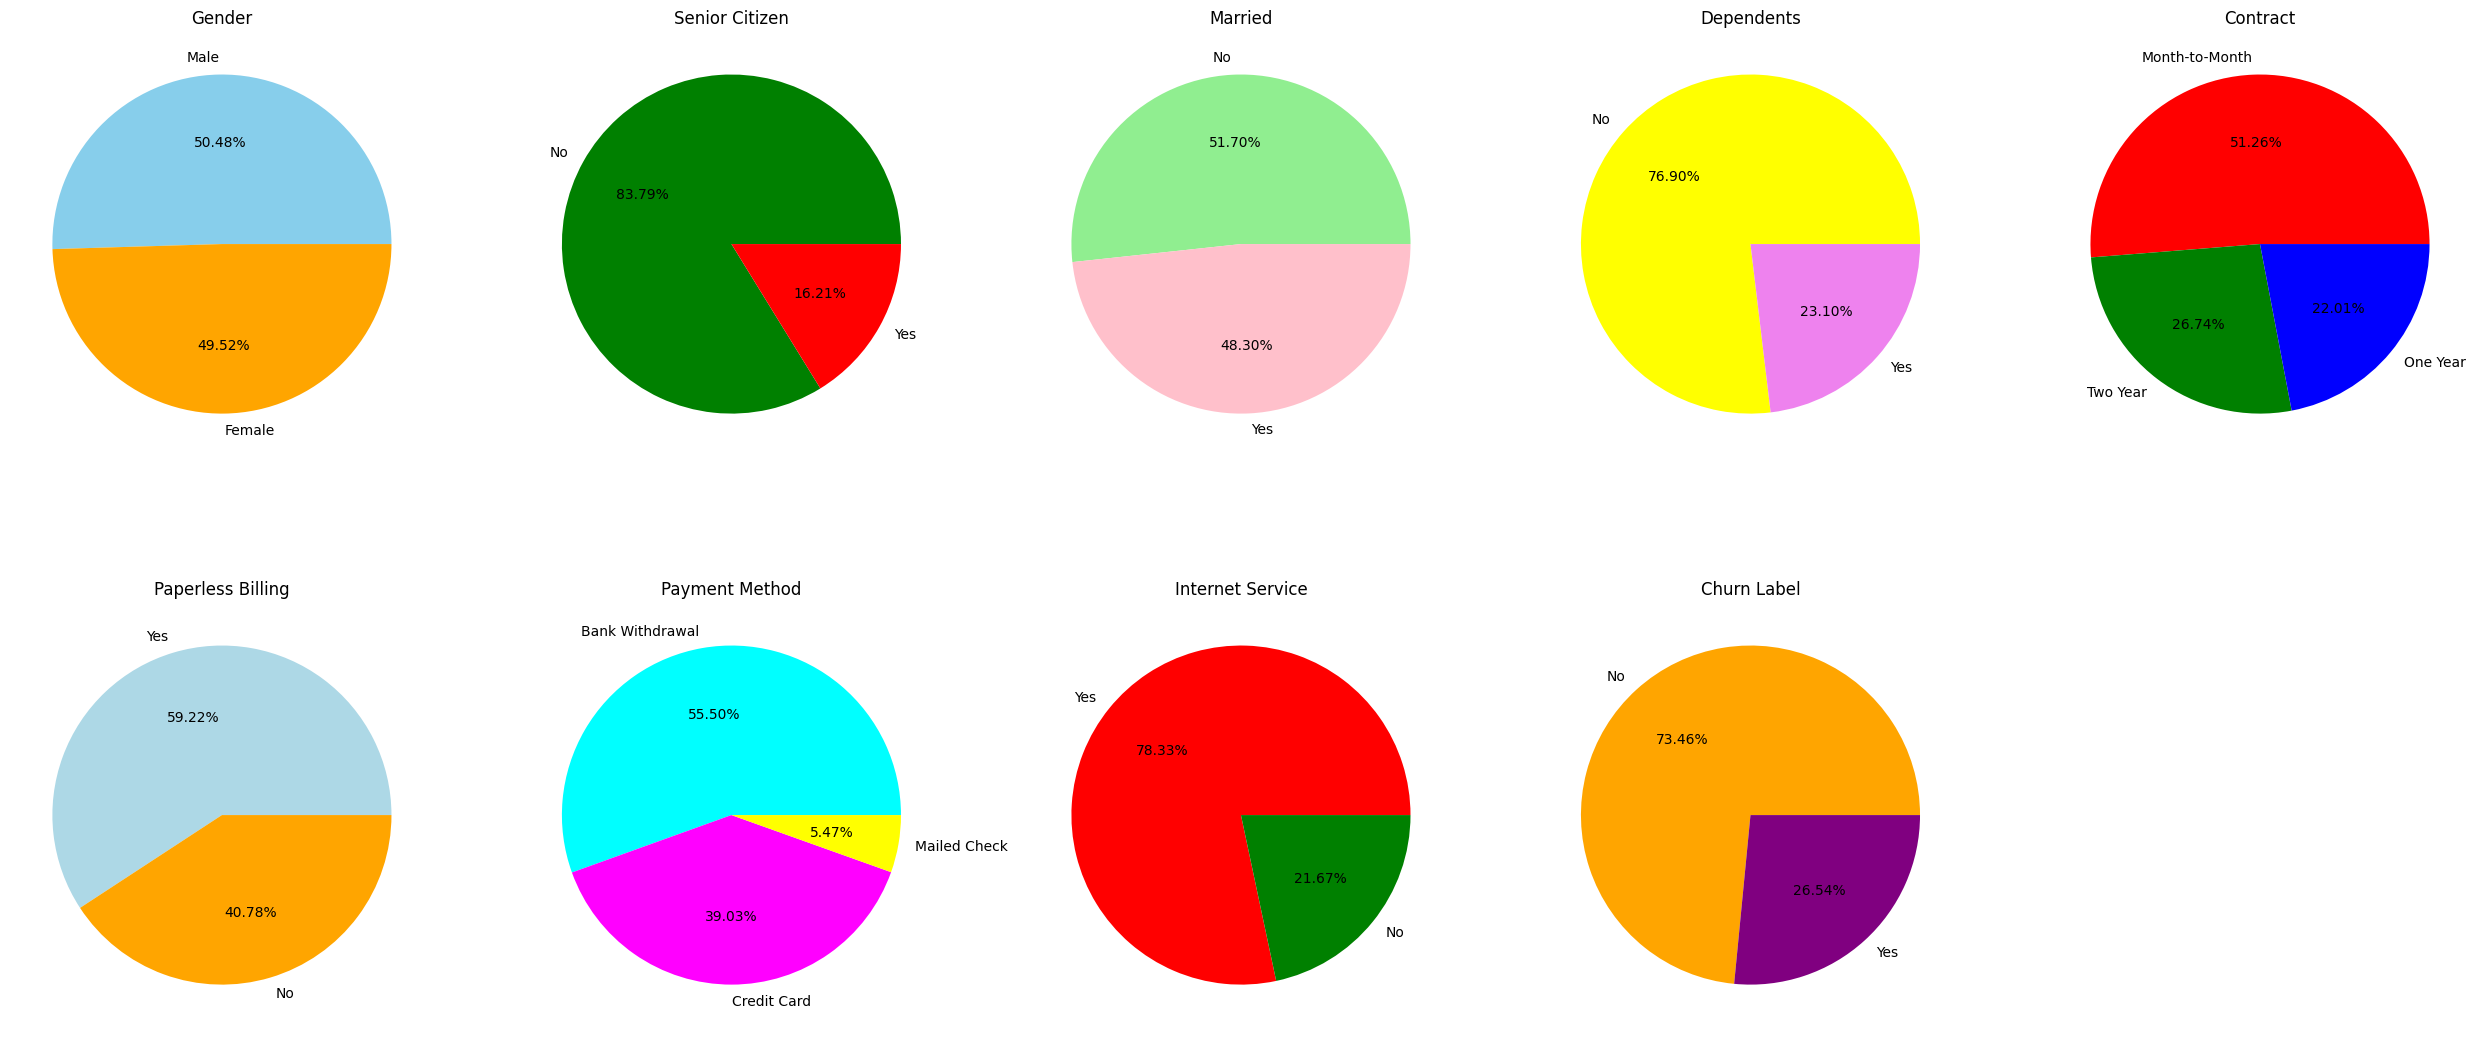

In [ ]:
# Categorical- Demographics Viz
import matplotlib.pyplot as plt


plt.rcParams['figure.figsize'] = (25, 12)


plt.subplot(2, 5, 1)
size = df['Gender'].value_counts()
labels = size.index
colors = ['skyblue','orange']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Gender')


plt.subplot(2, 5, 2)
size = df['Senior Citizen'].value_counts()
labels = size.index
colors = ['green','red']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Senior Citizen')


plt.subplot(2, 5, 3)
size = df['Married'].value_counts()
labels = size.index
colors = ['lightgreen','pink']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Married')


plt.subplot(2, 5, 4)
size = df['Dependents'].value_counts()
labels = size.index
colors = ['yellow','violet']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Dependents')


plt.subplot(2, 5, 5)
size = df['Contract'].value_counts()
labels = size.index
colors = ['red','green','blue']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Contract')


plt.subplot(2, 5, 6)
size = df['Paperless Billing'].value_counts()
labels = size.index
colors = ['lightblue','orange']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Paperless Billing')


plt.subplot(2, 5, 7)
size = df['Payment Method'].value_counts()
labels = size.index
colors = ['cyan','magenta','yellow','grey']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Payment Method')


plt.subplot(2, 5, 8)
size = df['Internet Service'].value_counts()
labels = size.index
colors = ['red','green','blue']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Internet Service')


plt.subplot(2, 5, 9)
size = df['Churn Label'].value_counts()
labels = size.index
colors = ['orange','purple']
plt.pie(size, colors=colors, labels=labels, autopct='%.2f%%')
plt.title('Churn Label')

plt.tight_layout()
plt.show()

Categorical Feature Insights (Pie Charts)

Based on the pie charts of key categorical features, the following insights can be drawn:

*Gender:* The customer base is nearly balanced with 51% Male and 49% Female.

*Senior Citizen:* Majority of customers (~84%) are not senior citizens, while only 16% are seniors.

*Married:* The split between married and unmarried customers is relatively even (~51% unmarried, 49% married).

*Dependents:* Most customers (~77%) have no dependents, suggesting a large portion of single or childless customers.

*Contract:* Month-to-Month contracts dominate (~51%), followed by Two Year (~27%) and One Year (~22%).
This aligns with higher churn risk for short-term contracts.

*Paperless Billing:* Most customers (~58%) have opted for paperless billing, indicating digital preference.

*Payment Method:* Bank Withdrawal is the most popular payment method (~53%), followed by Credit Card (~37%), and a small fraction uses Mailed Check (~5%).

*Internet Service:* A majority of customers (~78%) have Internet service, while 22% do not.

*Churn Label:* About 26% of customers have churned, while 74% have stayed, highlighting the churn risk in the dataset.

*Overall Observations:*

The dataset shows that short-term contracts, paperless billing, and certain payment methods may influence churn behavior.
Most customers are non-senior, with no dependents, and fairly evenly split by gender and marital status.
These insights help identify high-risk segments and inform retention strategies